## 02 — Comparing the LOD Levels

The four output files exist. Now we load them and answer:

1. How do the files differ in size, feature count, and coordinate count?
2. What does each level look like on a real map?
3. At what zoom does each level look correct — and at what zoom does it start to look wrong?

This is the quality check before we build the switching logic.

## Load All Four Levels

In [1]:
import json
from pathlib import Path

lod_dir = Path("../../data/lod")

lod_files = {
    "coarse":     "railroads_coarse.geojson",
    "medium":     "railroads_medium.geojson",
    "fine":       "railroads_fine.geojson",
    "extra_fine": "railroads_extra_fine.geojson",
}

lod_data = {}
for name, filename in lod_files.items():
    path = lod_dir / filename
    with open(path) as f:
        lod_data[name] = json.load(f)
    print(f"Loaded {name}: {len(lod_data[name]['features']):,} features")

Loaded coarse: 2,845 features
Loaded medium: 25,413 features
Loaded fine: 25,413 features
Loaded extra_fine: 25,413 features


## Summary Table — Size and Coordinate Count

In [2]:
print(f"{'Level':<12} {'Zoom':>6} {'Features':>10} {'Total pts':>12} {'File (MB)':>11}")
print("-" * 55)

zoom_ranges = {"coarse": "1-3", "medium": "4-6", "fine": "7-10", "extra_fine": "11+"}

for name, filename in lod_files.items():
    path = lod_dir / filename
    fc   = lod_data[name]
    n_features = len(fc["features"])
    total_pts  = sum(len(f["geometry"]["coordinates"]) for f in fc["features"])
    size_mb    = path.stat().st_size / 1_000_000
    zoom       = zoom_ranges[name]
    print(f"{name:<12} {zoom:>6} {n_features:>10,} {total_pts:>12,} {size_mb:>10.2f}")

# Also show the original for comparison
original_path = Path("../../data/ne_10m_railroads.geojson")
with open(original_path) as f:
    original = json.load(f)
orig_pts  = sum(len(f["geometry"]["coordinates"]) for f in original["features"])
orig_size = original_path.stat().st_size / 1_000_000
print("-" * 55)
print(f"{'original':<12} {'all':>6} {len(original['features']):>10,} {orig_pts:>12,} {orig_size:>10.2f}")

Level          Zoom   Features    Total pts   File (MB)
-------------------------------------------------------
coarse          1-3      2,845        5,690       1.08
medium          4-6     25,413       55,516       9.66
fine           7-10     25,413      124,844      11.34
extra_fine      11+     25,413      441,890      18.98
-------------------------------------------------------
original        all     25,413    1,396,480      39.60


## Visual Comparison — One Level at a Time

Display each LOD level on a map. Pan and zoom to see where it starts to look correct and where it breaks down.

In [3]:
from ipyleaflet import Map, GeoJSON
import ipywidgets as widgets

# Change this to switch between levels: "coarse", "medium", "fine", "extra_fine"
level = "coarse"

level_zoom = {"coarse": 2, "medium": 4, "fine": 7, "extra_fine": 10}

m = Map(center=[20, 0], zoom=level_zoom[level])
layer = GeoJSON(
    data=lod_data[level],
    style={"color": "#cc3300", "weight": 1.5, "opacity": 0.8}
)
m.add(layer)

print(f"Showing: {level}  |  {len(lod_data[level]['features']):,} features")
m

Showing: coarse  |  2,845 features


Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

Try each level at its intended zoom range. Then deliberately zoom in too far on the coarse level — you should see the simplification artifacts clearly: straight lines where there should be curves.

## Side-by-Side Comparison — One Region

To see the difference sharply, let's crop to a small geographic area and display all four levels.

We filter to features whose bounding box falls within Europe (roughly).

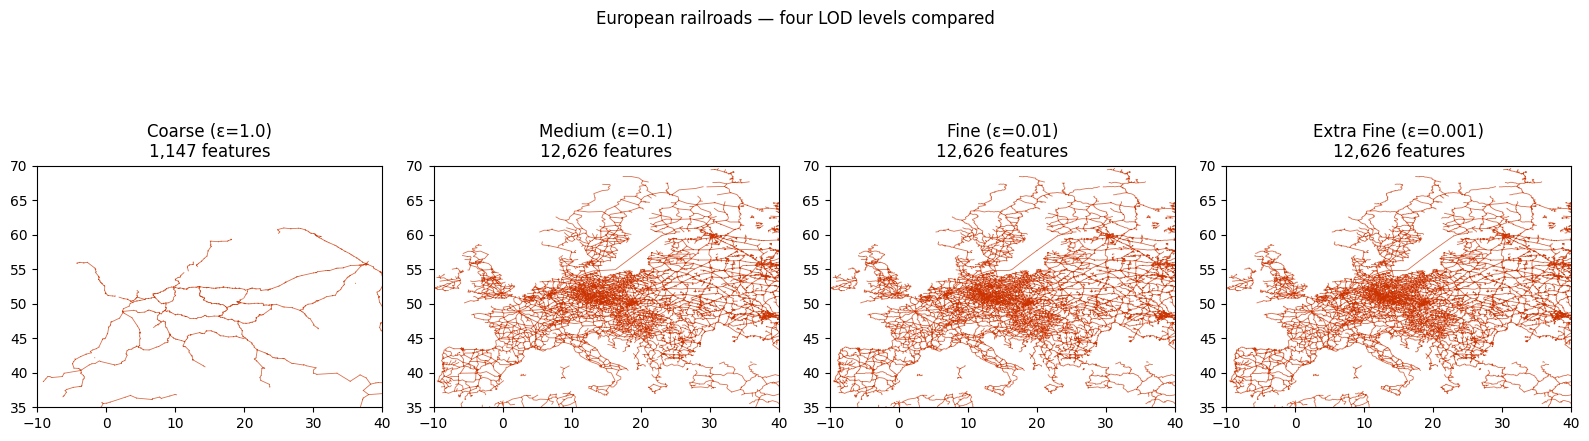

In [4]:
import matplotlib.pyplot as plt

# Europe bounding box [lon_min, lat_min, lon_max, lat_max]
europe = (-10, 35, 40, 70)

def coords_in_bbox(coords, bbox):
    lon_min, lat_min, lon_max, lat_max = bbox
    return any(
        lon_min <= c[0] <= lon_max and lat_min <= c[1] <= lat_max
        for c in coords
    )

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
titles = ["Coarse (ε=1.0)", "Medium (ε=0.1)", "Fine (ε=0.01)", "Extra Fine (ε=0.001)"]

for ax, (name, _), title in zip(axes, lod_files.items(), titles):
    europe_features = [
        f for f in lod_data[name]["features"]
        if coords_in_bbox(f["geometry"]["coordinates"], europe)
    ]
    for f in europe_features:
        xs = [c[0] for c in f["geometry"]["coordinates"]]
        ys = [c[1] for c in f["geometry"]["coordinates"]]
        ax.plot(xs, ys, '-', color='#cc3300', linewidth=0.6, alpha=0.7)
    ax.set_xlim(europe[0], europe[2])
    ax.set_ylim(europe[1], europe[3])
    ax.set_title(f"{title}\n{len(europe_features):,} features")
    ax.set_aspect('equal')

plt.suptitle('European railroads — four LOD levels compared', y=1.02)
plt.tight_layout()
plt.show()

The coarse level will show far fewer features (scalerank filter) and angular lines. The extra fine level should look nearly identical to the original.

## Exercise A

Pick one specific railroad feature that appears in all four LOD files — use the `rwdb_rr_id` property to find the same feature across files.

Plot that single feature at all four simplification levels on one chart. Label each with its point count.

Number of features found in all four LOD levels: 2845
Chosen rwdb_rr_id: 16387


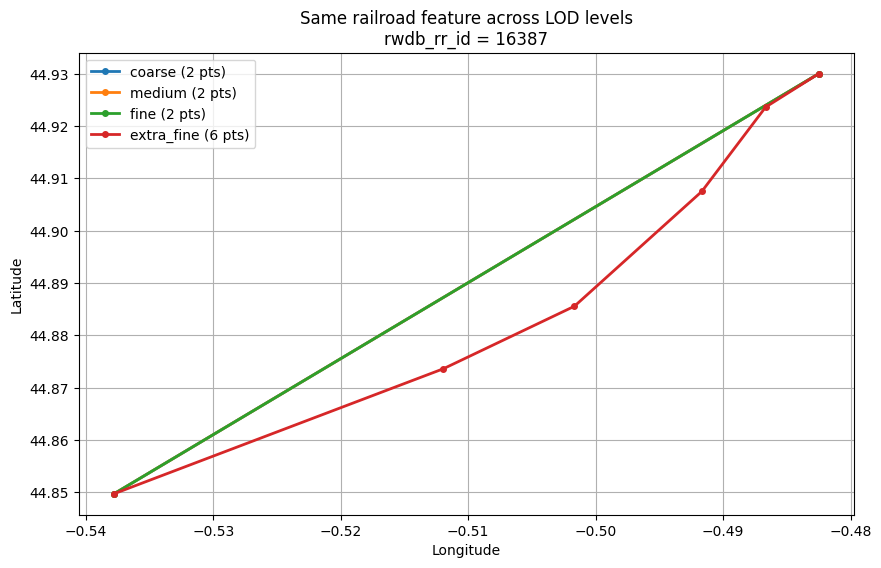

In [5]:
import matplotlib.pyplot as plt

# Find rwdb_rr_id values that exist in every LOD level
id_sets = []

for name in lod_data:
    ids = {
        f["properties"].get("rwdb_rr_id")
        for f in lod_data[name]["features"]
        if f["properties"].get("rwdb_rr_id") is not None
    }
    id_sets.append(ids)

common_ids = set.intersection(*id_sets)

print("Number of features found in all four LOD levels:", len(common_ids))

# Pick one common feature ID
chosen_id = list(common_ids)[0]
print("Chosen rwdb_rr_id:", chosen_id)

# Plot that same feature at each LOD level
plt.figure(figsize=(10, 6))

for name in ["coarse", "medium", "fine", "extra_fine"]:
    feature = next(
        f for f in lod_data[name]["features"]
        if f["properties"].get("rwdb_rr_id") == chosen_id
    )

    coords = feature["geometry"]["coordinates"]
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]

    plt.plot(xs, ys, marker="o", linewidth=2, markersize=4,
             label=f"{name} ({len(coords)} pts)")

plt.title(f"Same railroad feature across LOD levels\nrwdb_rr_id = {chosen_id}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()

## Exercise B

Calculate the **compression ratio** for each LOD level — the ratio of original coordinate count to simplified coordinate count for the features they share.

Then answer: which level gives the best size reduction per unit of visual quality loss?

In [6]:
# Build lookup tables by rwdb_rr_id
original_lookup = {
    f["properties"].get("rwdb_rr_id"): f
    for f in original["features"]
    if f["properties"].get("rwdb_rr_id") is not None
}

print(f"{'Level':<12} {'Original Pts':>15} {'Simplified Pts':>18} {'Compression Ratio':>20}")
print("-" * 70)

for level in ["coarse", "medium", "fine", "extra_fine"]:

    simplified_lookup = {
        f["properties"].get("rwdb_rr_id"): f
        for f in lod_data[level]["features"]
        if f["properties"].get("rwdb_rr_id") is not None
    }

    shared_ids = set(original_lookup.keys()) & set(simplified_lookup.keys())

    original_pts = 0
    simplified_pts = 0

    for rr_id in shared_ids:
        original_pts += len(original_lookup[rr_id]["geometry"]["coordinates"])
        simplified_pts += len(simplified_lookup[rr_id]["geometry"]["coordinates"])

    compression_ratio = original_pts / simplified_pts

    print(f"{level:<12} {original_pts:>15,} {simplified_pts:>18,} {compression_ratio:>19.2f}")

Level           Original Pts     Simplified Pts    Compression Ratio
----------------------------------------------------------------------
coarse               230,792              5,690               40.56
medium             1,395,426             55,497               25.14
fine               1,395,426            124,760               11.18
extra_fine         1,395,426            441,599                3.16


The coarse level gives the best size reduction because it removes the most coordinate detail and filters less important features. However, it also loses the most visual detail. The medium level is probably the best balance because it still reduces file size a lot while keeping most of the important railroad shapes visible.

## Check Your Understanding

The coarse level has far fewer features than the other levels because of the `scalerank <= 4` filter.

If a user zooms into a region that has no coarse-level features (e.g. a small country whose railroads are all scalerank 5+), what will they see? And what does this tell us about a limitation of the simple scalerank filter approach?

Write a 2–3 sentence answer.

---

If a region has no railroads with scalerank 4 or lower, the user may see an empty map at the coarse zoom level. This shows a limitation of using only scalerank filtering because some smaller regions can lose all representation even though they still have valid railroad networks. A better system might combine scalerank with regional coverage rules so every area still shows some important features.

## Next

In [Module 03 — Bounding Box Culling](../03-Bounding_Box_Culling/README.md), we add viewport filtering — so we only render the features the user can actually see.